## 기본 통계량 및 분포 분석

## 뉴욕 지역별 숙소 특성 및 가격 분포 분석
### 목적 : 뉴욕 어떤 숙소 유형으로 시작하는게 유리할까?
- 지역별 숙소 개수 → 현황같은데.. +시각화 → 여기서 더 추가할 수 있나?
- 지역별 평균 가격 → 지역별로 평균 가격에 차이가 있을 것이다.
- 숙소 유형별 가격 비교 → 숙소 유형에 따라 가격에 차이가 있을 것이다.
- 리뷰나 평점 → 상관계수 .........

---
## 데이터로드

In [127]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [128]:
#데이터 불러오깅
df = pd.read_csv("data/first_clean_data.csv", index_col=0)


In [129]:
df.shape

(22248, 38)

In [130]:
df.info()

<class 'pandas.DataFrame'>
Index: 22248 entries, 0 to 37433
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            22248 non-null  int64  
 1   name                                          22248 non-null  str    
 2   description                                   22248 non-null  str    
 3   host_id                                       22248 non-null  int64  
 4   host_since                                    22248 non-null  str    
 5   host_response_time                            22248 non-null  float64
 6   host_response_rate                            22248 non-null  float64
 7   host_acceptance_rate                          22248 non-null  float64
 8   host_is_superhost                             22248 non-null  str    
 9   neighbourhood_cleansed                        22248 non-null  str    
 10  ne

In [131]:
df.head()

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197


In [132]:
df.columns

Index(['id', 'name', 'description', 'host_id', 'host_since',
       'host_response_time', 'host_response_rate', 'host_acceptance_rate',
       'host_is_superhost', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'latitude', 'longitude',
       'property_type', 'room_type', 'accommodates', 'bedrooms', 'beds',
       'amenities', 'price', 'availability_365', 'number_of_reviews',
       'number_of_reviews_ltm', 'estimated_occupancy_l365d',
       'estimated_revenue_l365d', 'review_scores_rating',
       'review_scores_accuracy', 'review_scores_cleanliness',
       'review_scores_checkin', 'review_scores_communication',
       'review_scores_location', 'review_scores_value',
       'calculated_host_listings_count',
       'calculated_host_listings_count_entire_homes',
       'calculated_host_listings_count_private_rooms',
       'calculated_host_listings_count_shared_rooms', 'reviews_per_month',
       'log_price'],
      dtype='str')

In [133]:
df[['price','log_price']]

,price,log_price
0,200,5.303305
1,82,4.418841
2,765,6.641182
3,139,4.941642
4,130,4.875197
...,...,...
37429,72,4.290459
37430,58,4.077537
37431,299,5.703782
37432,200,5.303305


---
## 숙소 유형별 가격 비교

In [134]:
df.groupby("room_type")["price"].count().sort_values(ascending=False)

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: price, dtype: int64

In [135]:
df.groupby("room_type")["price"].mean().sort_values(ascending=False)

room_type
Hotel room         537.600000
Entire home/apt    265.557657
Shared room        169.728571
Private room       130.826869
Name: price, dtype: float64

<Axes: title={'center': 'price'}, xlabel='room_type'>

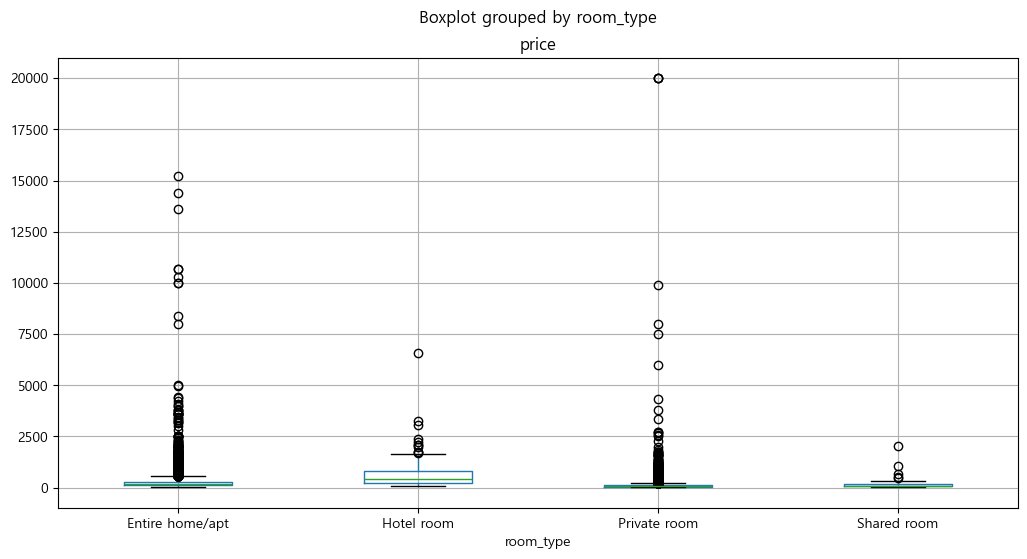

In [136]:
df.boxplot(column="price", by="room_type")

<Axes: title={'center': 'log_price'}, xlabel='room_type'>

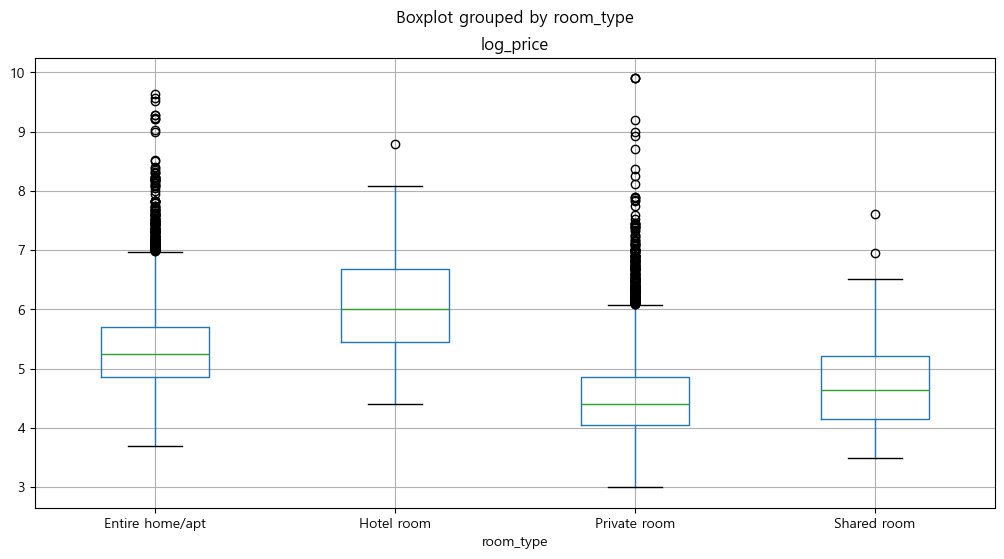

In [137]:
# 가격 log씌워서 boxplot
df.boxplot(column="log_price", by="room_type")

- Hotel의 중앙값(초록색) 가장 높아 가장 비싼 유형이다.
- Entire home/apt는 그다음으로 중앙값(초록색)이 높다.
- Private room과 Shared room의 중앙값(초록색)은 비슷했다.
- Shared room은 박스가 Private room에 비해 넓어 가격 변동이 조금 더 커 보인다.

## 숙소 유형별 차이가 유의미한가?

### 1. 가설설정
- 귀무가설 : 숙소 유형별로 평균 가격은 같다.
- 대립가설 : 숙소 유형별로 평균 가격이 다르다.

Entire home/apt, Hotel room, Private room, Shared room

In [138]:
df['room_type'].value_counts()

room_type
Entire home/apt    12635
Private room        9178
Hotel room           365
Shared room           70
Name: count, dtype: int64

In [139]:
g1 = df.loc[df['room_type']=='Entire home/apt','price']
g2 = df.loc[df['room_type']=='Private room','price']
g3 = df.loc[df['room_type']=='Hotel room','price']
g4 = df.loc[df['room_type']=='Shared room','price']

### 2. 검정방법 선택
- 후보1: 일원 ANOVA
    - 조건에 맞는지 1)정규성 2)등분산성 3)독립성 

#### 2-1) 정규성 확인하기

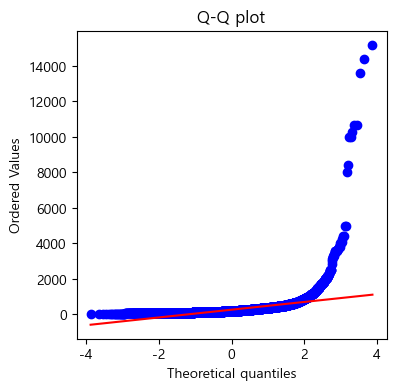

In [140]:
# q-q plot 

plt.figure(figsize=(4,4))
stats.probplot(g1, plot=plt)
plt.title("Q-Q plot")
plt.show()

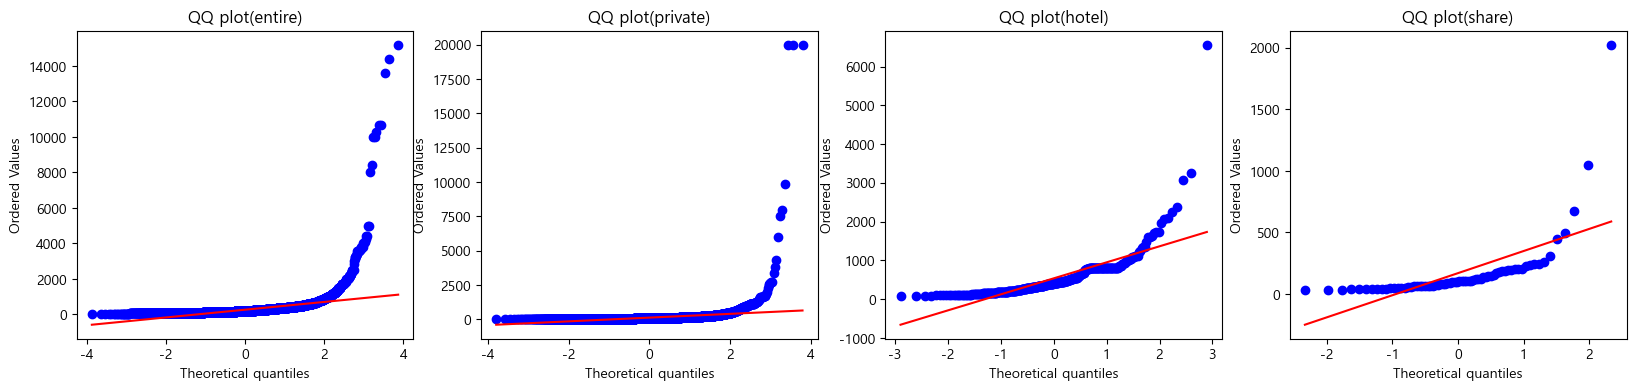

In [141]:
# q-q plot 시각화
fig, ax = plt.subplots(1,4, figsize=(20,4))
stats.probplot(g1, plot=ax[0])
ax[0].set_title("QQ plot(entire)")
stats.probplot(g2, plot=ax[1])
ax[1].set_title("QQ plot(private)")
stats.probplot(g3, plot=ax[2])
ax[2].set_title("QQ plot(hotel)")
stats.probplot(g4, plot=ax[3])
ax[3].set_title("QQ plot(share)")
plt.show()

- 정규성을 만족하지 않음
- 롱테일(오른쪽 꼬리가 긴 형태)

### 3. 유의수준 결정 : 0.05

### 4. 검정 통계량, p-value 계산

In [142]:
stat, p = stats.kruskal(g1, g2, g3, g4)
stat, p

(np.float64(7284.52185170291), np.float64(0.0))

### 5. 결과해석

p-value가 유의수준보다 낮으므로 귀무가설 기각.(p < 0.05)

- 귀무가설 : 숙소 유형별로 평균 가격은 같다.
- 대립가설 : 숙소 유형별로 평균 가격이 다르다.

## 사후검정 (Dunn test)

In [143]:
# Dunn 사후검정 
data = df_ch[['room_type', 'price']].dropna()

posthoc = sp.posthoc_dunn(data, 
                        val_col="price",
                        group_col="room_type",
                        p_adjust="holm"
                        )

In [144]:
posthoc

,Entire home/apt,Hotel room,Private room,Shared room
Entire home/apt,1.000000e+00,4.350104e-37,0.000000e+00,2.217586e-13
Hotel room,4.350104e-37,1.000000e+00,8.469899e-252,6.290908e-33
Private room,0.000000e+00,8.469899e-252,1.000000e+00,4.542803e-02
Shared room,2.217586e-13,6.290908e-33,4.542803e-02,1.000000e+00


**해석 : Entire home/apt, Hotel room, Private room, Shared room 평균가격이 모두 서로 다르다 ( 유의 수준 0.05 기준)**

---
# 카이제곱 독립성 검정

- 귀무가설 : 두 범주형 변수는 독립적이다.
- 대립가설 : 두 범주형 변수는 독립적이지 않다.

In [145]:
df

,id,name,description,host_id,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bedrooms,beds,amenities,price,availability_365,number_of_reviews,number_of_reviews_ltm,estimated_occupancy_l365d,estimated_revenue_l365d,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,log_price
0,36121,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,62165,2009-12-11,-1.0,-1.0,87.0,False,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",200,362,9,0,0,0.0,4.88,5.00,4.80,5.00,5.00,5.00,5.00,1,0,1,0,0.05,5.303305
1,36647,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,157798,2010-07-04,-1.0,-1.0,100.0,False,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",82,204,102,0,0,0.0,4.77,4.82,4.76,4.88,4.90,4.38,4.71,1,0,1,0,0.58,4.418841
2,38663,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...",165789,2010-07-13,3.0,100.0,40.0,False,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",765,326,43,0,0,0.0,4.70,4.83,4.52,4.88,4.88,4.86,4.62,1,0,1,0,0.28,6.641182
3,38833,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,166532,2010-07-14,4.0,100.0,97.0,True,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",139,25,241,42,255,35445.0,4.85,4.87,4.50,4.96,4.96,4.79,4.82,1,1,0,0,1.36,4.941642
4,39282,“Work-from-home” from OUR home.,*Monthly Discount will automatically apply <br...,168525,2010-07-16,4.0,100.0,100.0,True,Williamsburg,Brooklyn,40.710651,-73.950874,Private room in rental unit,Private room,2,1.0,1.0,"[""Oven"", ""Rice maker"", ""Laundromat nearby"", ""L...",130,38,274,12,154,20020.0,4.82,4.83,4.61,4.94,4.88,4.85,4.78,2,0,2,0,1.54,4.875197
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37429,1366333532374850165,Beautiful 1-Bed Apt in Harlem!,Welcome to your temporary home in the vibrant ...,40019013,2015-07-30,-1.0,-1.0,87.0,False,Harlem,Manhattan,40.813794,-73.952399,Private room in rental unit,Private room,1,1.0,1.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",72,358,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,1,0,NaN,4.290459
37430,1366717321390111215,Private Room w/ Ensuite Bath H,Stylish Private Rooms w/ En-Suite Baths in Bro...,483056418,2022-10-10,4.0,100.0,80.0,True,Bedford-Stuyvesant,Brooklyn,40.685500,-73.919510,Private room in rental unit,Private room,2,1.0,0.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",58,363,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,0,24,0,NaN,4.077537
37431,1366721904709517353,2 Bedroom on East Side,Located in the Murray Hill area and occupies a...,30283594,2015-03-30,4.0,94.0,99.0,False,Kips Bay,Manhattan,40.745290,-73.979380,Entire rental unit,Entire home/apt,5,2.0,3.0,"[""Air conditioning"", ""Carbon monoxide alarm"", ...",299,99,0,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48,48,0,0,NaN,5.703782
37432,1366722692755341871,Stylish 2Bd near Bryant Park,Enjoy everything the city has to offer while l...,407304997,2021-06-15,4.0,89.0,100.0,False,Theater District,Manhattan,40.757133,-73.983124,Entire rental unit,Entire home/apt,4,2.0,2.0,"[""Oven"", "

In [146]:
display(df['neighbourhood_group_cleansed'].isna().sum())
display(df['neighbourhood_group_cleansed'].value_counts(dropna=False))

np.int64(0)

neighbourhood_group_cleansed
Manhattan        10165
Brooklyn          7442
Queens            3414
Bronx              911
Staten Island      316
Name: count, dtype: int64

In [153]:
ct = pd.crosstab(df['room_type'], df['neighbourhood_group_cleansed'])
result = chi2_contingency(ct)

result

Chi2ContingencyResult(statistic=np.float64(1646.3567796675218), pvalue=np.float64(0.0), dof=12, expected_freq=array([[5.17371674e+02, 4.22643249e+03, 5.77286835e+03, 1.93886597e+03,
        1.79461525e+02],
       [1.49458378e+01, 1.22093222e+02, 1.66766676e+02, 5.60099784e+01,
        5.18428623e+00],
       [3.75816163e+02, 3.07005915e+03, 4.19338233e+03, 1.40838242e+03,
        1.30359942e+02],
       [2.86632506e+00, 2.34151384e+01, 3.19826501e+01, 1.07416397e+01,
        9.94246674e-01]]))

p-value가 0에 가까우니까 두 범주형 변수는 관계가 있다.

# 크래머 v계수 계산하기

In [150]:
def cramers_v(contingency_table):
    chi2 = chi2_contingency(contingency_table).statistic
    n = contingency_table.sum().sum()
    r = contingency_table.shape[0]
    c = contingency_table.shape[1]
    v = np.sqrt(chi2/(n*min(r-1,c-1)))
    return v

In [152]:
cramers_v(ct)

np.float64(0.15705648117352444)

크래머V 계수가 0.1이상으로 약한 상관관계가 있다.